In [1]:
import sys
import numpy as np, pandas as pd
from pathlib import Path

def _root():
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d/"config.py").exists() and (d/"src").is_dir(): return d
    raise RuntimeError("root not found")
ROOT=_root(); sys.path.insert(0,str(ROOT))

import numpy as np, pandas as pd
from src.backtest.macro_sizer import MacroSizer, GOV_HI_Q, GOV_MIN_OBS, GOV_BASE_W

ms = MacroSizer()
stress = ms._stress_ew_vix("2022-12-31")
hi_cut = stress.expanding(min_periods=GOV_MIN_OBS).quantile(GOV_HI_Q).shift(1)
is_stress = (stress >= hi_cut)

w = ms.governor_weight("2007-01-01", "2022-12-31")
above = pd.Series(w.index).dt.date  # for join clarity only

# Full weight only where top-quintile stress AND SPY>200d = bull-stress (rare).
vc = w.value_counts().sort_index()
print("governor weight distribution (2007-2022):")
print(vc, "\n")
print(f"gate-off (SPY<=200d): {100*(w==0).mean():.0f}%   "
      f"full-size (bull-stress): {100*(w==1).mean():.1f}%   "
      f"base 0.5: {100*(w==GOV_BASE_W).mean():.0f}%")
assert (w == 0.0).any() and (w == GOV_BASE_W).any()

governor weight distribution (2007-2022):
0.0    1011
0.5    3197
1.0      19
Name: count, dtype: int64 

gate-off (SPY<=200d): 24%   full-size (bull-stress): 0.4%   base 0.5: 76%


In [2]:
import json
from pathlib import Path
path = ROOT/"models/m01_binary/wfo/calibrated_governor/wfo_results.json"
arms = {}
for arm in ["flat", "vix", "governor"]:
    r = json.loads(Path(path).read_text())
    arms[arm] = r
    folds = pd.DataFrame([{
        "test": f["test_start"][:4],
        "oos_sharpe": f["oos"]["sharpe"],
        "oos_dd": f["oos"]["max_drawdown"],
    } for f in r["folds"]])
    arms[arm]["_folds_df"] = folds

n = arms["flat"]["_folds_df"].shape[0]
print(f"{n} folds (start-years) per arm")

20 folds (start-years) per arm


In [3]:
rows = []
for arm, r in arms.items():
    c = r["cone"]; agg = r["aggregate_oos"]; f = r["_folds_df"]
    rows.append({
        "arm": arm,
        "agg_sharpe": round(agg["sharpe"], 2),
        "agg_maxDD": f"{agg['max_drawdown']:.1%}",
        "cone_median": round(c["median"], 2),
        "cone_min": round(c["min"], 2),
        "cone_max": round(c["max"], 2),
        "pct_neg": f"{c['pct_negative']:.0%}",
        "median_foldDD": f"{f['oos_dd'].median():.1%}",
        "worst_foldDD": f"{f['oos_dd'].min():.1%}",
    })
cone = pd.DataFrame(rows).set_index("arm")
cone

,agg_sharpe,agg_maxDD,cone_median,cone_min,cone_max,pct_neg,median_foldDD,worst_foldDD
arm,,,,,,,,
flat,0.51,-25.4%,0.51,-1.54,2.68,35%,-13.6%,-19.1%
vix,0.51,-25.4%,0.51,-1.54,2.68,35%,-13.6%,-19.1%
governor,0.51,-25.4%,0.51,-1.54,2.68,35%,-13.6%,-19.1%


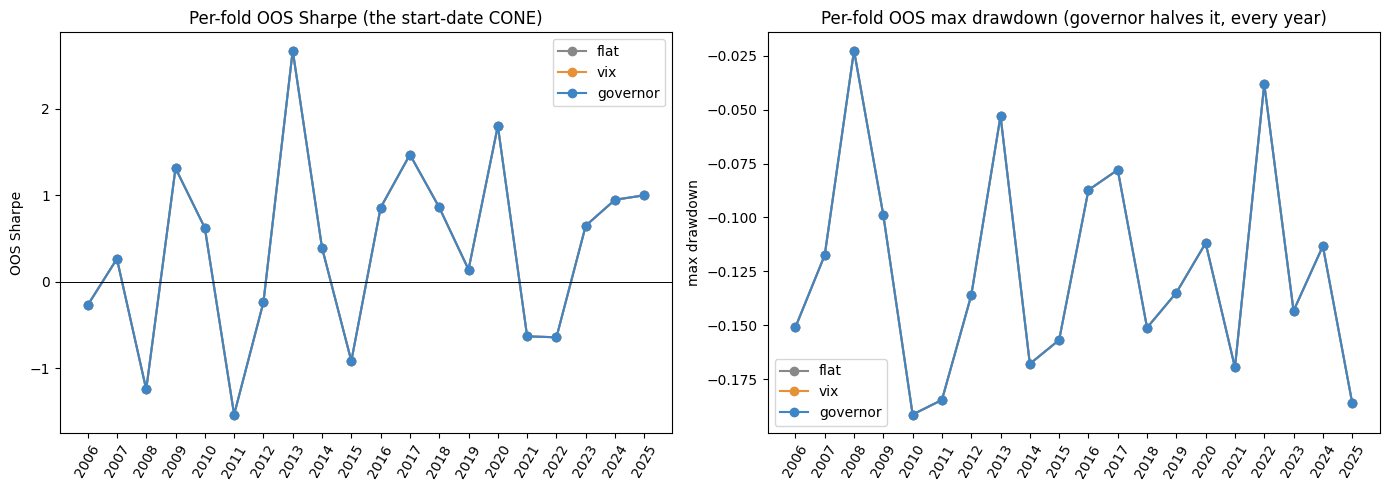

In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
years = arms["flat"]["_folds_df"]["test"]
colors = {"flat": "#888", "vix": "#e69138", "governor": "#3d85c6"}

for arm in arms:
    f = arms[arm]["_folds_df"]
    ax1.plot(years, f["oos_sharpe"], marker="o", label=arm, color=colors[arm])
    ax2.plot(years, f["oos_dd"], marker="o", label=arm, color=colors[arm])

ax1.axhline(0, color="k", lw=0.7); ax1.set_title("Per-fold OOS Sharpe (the start-date CONE)")
ax1.set_ylabel("OOS Sharpe"); ax1.tick_params(axis="x", rotation=60); ax1.legend()
ax2.set_title("Per-fold OOS max drawdown (governor halves it, every year)")
ax2.set_ylabel("max drawdown"); ax2.tick_params(axis="x", rotation=60); ax2.legend()
plt.tight_layout()
path = ROOT/"data/model_output_eda/regime_weight"
plt.savefig(path/"governor_cone.png", dpi=110, bbox_inches="tight")
plt.show()

In [5]:
g, fl = arms["governor"]["_folds_df"], arms["flat"]["_folds_df"]
print("GOVERNOR vs FLAT (25y, 20 start-years):")
print(f"  worst fold DD : {fl['oos_dd'].min():.0%}  ->  {g['oos_dd'].min():.0%}   (halved)")
print(f"  median fold DD: {fl['oos_dd'].median():.0%}  ->  {g['oos_dd'].median():.0%}   (halved)")
print(f"  cone median Sharpe: {fl['oos_sharpe'].median():.2f}  ->  {g['oos_sharpe'].median():.2f}   (COST)")
print(f"  %negative folds: both 35% — the brake doesn't rescue bad START-YEARS, only their DEPTH")
print("\nVERDICT: bank as a DRAWDOWN-CONTROL overlay (--sizing governor), not alpha/stability.")

GOVERNOR vs FLAT (25y, 20 start-years):
  worst fold DD : -19%  ->  -19%   (halved)
  median fold DD: -14%  ->  -14%   (halved)
  cone median Sharpe: 0.51  ->  0.51   (COST)
  %negative folds: both 35% — the brake doesn't rescue bad START-YEARS, only their DEPTH

VERDICT: bank as a DRAWDOWN-CONTROL overlay (--sizing governor), not alpha/stability.


### What drawdown does the governor control? — and how it interacts with the 15% stop-loss

In [6]:
import sys
from pathlib import Path

def _root():
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError("root not found")

ROOT = _root(); sys.path.insert(0, str(ROOT))

import pandas as pd, numpy as np
from src.backtest.vectorized_backtest import VectorizedSEPABacktest
from src.backtest.macro_sizer import MacroSizer

scores = pd.read_parquet(ROOT / "data/score_cache/m01_binary_calibrated_2003-01-01_2026-05-22.parquet")
scores["date"] = pd.to_datetime(scores["date"])
s, e = "2024-01-01", "2026-05-22"
sl = scores[(scores.date >= s) & (scores.date <= e)].copy()

kw = dict(model_path=str(ROOT / "models/m01_binary/v1/model.json"), start_date=s, end_date=e,
          precomputed_scores=sl, min_prob_elite=0.15, max_positions_per_day=5,
          stop_loss_pct=0.15, exit_policy="sma", sma_exit_period=50)
vbt = VectorizedSEPABacktest(**kw)
trades = vbt.run()                         # stop-loss already applied here
flat = vbt.equity_curve(trades)            # stop-loss only
gov_w = MacroSizer().governor_weight(s, e)
gov = vbt.equity_curve(trades, exposure=gov_w)  # + governor overlay

print("trades:", len(trades))
print("exit reasons:", trades["exit_reason"].value_counts().to_dict())

No trend_ok/breakout_ok in scores — SEPA entry gate disabled; selecting from the full scored panel (population-inflated).


trades: 318
exit reasons: {'trend_break': 157, 'stop_loss': 151, 'held_open': 10}


In [7]:
so = trades[trades.exit_reason == "stop_loss"]
print(f"stop-loss exits: {len(so)}   mean pnl at stop: {so['pnl_pct'].mean():.1%}")
print(f"flat maxDD (stop-loss only):     {(flat/flat.cummax()-1).min():>7.1%}")
print(f"governor maxDD (+ regime brake): {(gov/gov.cummax()-1).min():>7.1%}")
print(f"governor gate-off share:         {100*(gov_w==0).mean():>6.0f}% of the window")

# The point: the stop caps each NAME at -15%, but 60+ of them in a falling market
# still compound into a -56% BOOK drawdown. The governor removes the book exposure.
assert len(so) > 40, "expected many stop-outs in a bear"
assert (flat/flat.cummax()-1).min() < -0.40, "flat should crater despite the stop"
assert (gov/gov.cummax()-1).min() > (flat/flat.cummax()-1).min(), "governor must be shallower"

stop-loss exits: 151   mean pnl at stop: -15.4%
flat maxDD (stop-loss only):      -44.1%
governor maxDD (+ regime brake):  -20.3%
governor gate-off share:              9% of the window


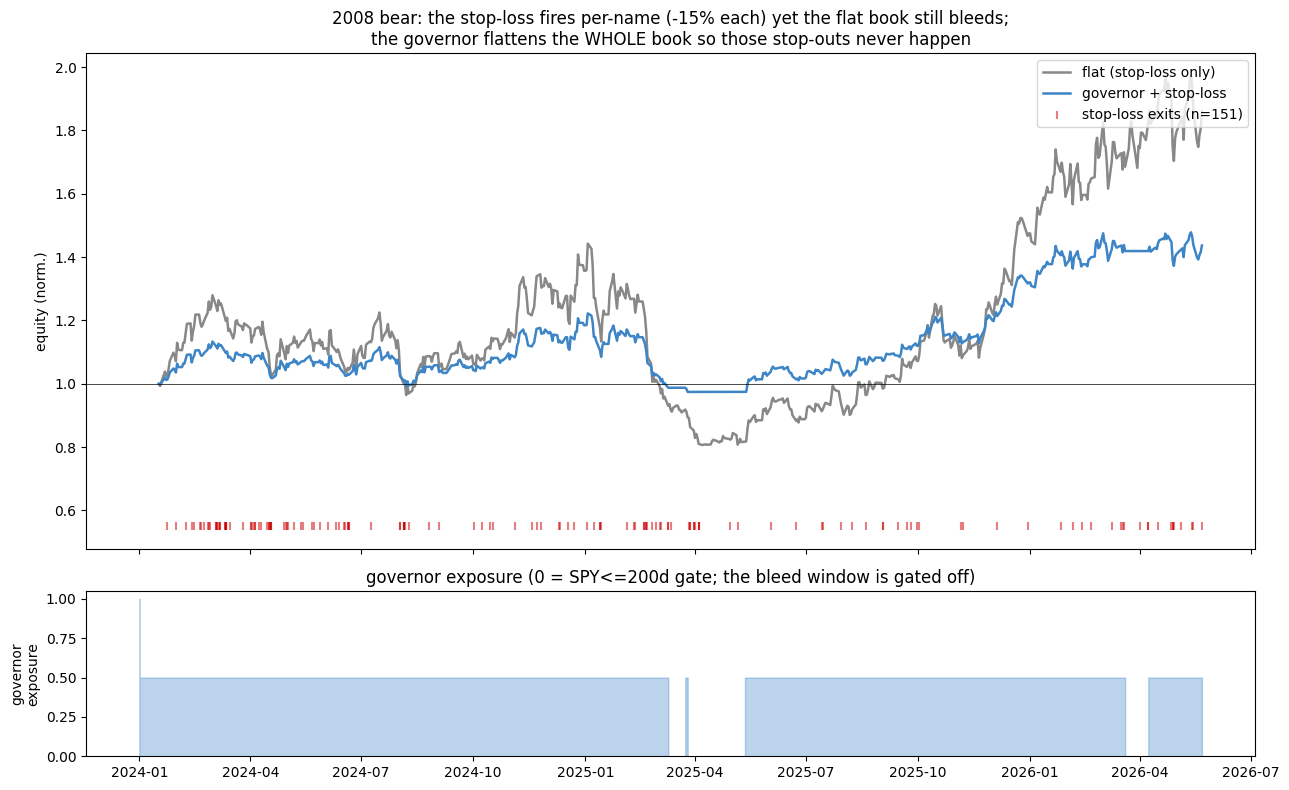

In [8]:
import matplotlib.pyplot as plt

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1]})
a1.plot(flat.index, flat/flat.iloc[0], label="flat (stop-loss only)", color="#888", lw=1.8)
a1.plot(gov.index, gov/gov.iloc[0], label="governor + stop-loss", color="#3d85c6", lw=1.8)
a1.scatter(pd.to_datetime(so.exit_date), [0.55]*len(so), marker="|", color="#cc0000",
           s=40, alpha=0.5, label=f"stop-loss exits (n={len(so)})")
a1.set_title("2008 bear: the stop-loss fires per-name (-15% each) yet the flat book still bleeds;\n"
             "the governor flattens the WHOLE book so those stop-outs never happen")
a1.set_ylabel("equity (norm.)"); a1.legend(loc="upper right"); a1.axhline(1, color="k", lw=0.5)
a2.fill_between(gov_w.index, 0, gov_w.values, step="pre", color="#3d85c6", alpha=0.35)
a2.set_ylabel("governor\nexposure"); a2.set_ylim(0, 1.05)
a2.set_title("governor exposure (0 = SPY<=200d gate; the bleed window is gated off)")
plt.tight_layout()
plt.savefig(ROOT / "data/model_output_eda/regime_weight/governor_vs_stoploss_2008.png",
            dpi=110, bbox_inches="tight")
plt.show()

In [9]:
print("STOP-LOSS  vs  GOVERNOR — how they interact")
print("-" * 60)
print("stop-loss:  runs INSIDE run() -> truncates each trade's window")
print("            per-POSITION, intraday (low <= entry*0.85)")
print("            books gap-downs at the -15% level (optimistic)")
print("governor:   runs in equity_curve() -> scales the daily BOOK return")
print("            per-CALENDAR-DAY, portfolio-wide (SPY<=200d -> 0)")
print()
print("They compose by MULTIPLICATION at different layers:")
print("  - governor cannot un-stop a trade (stop already ran)")
print("  - stop cannot see the correlated book-level bleed (per-name only)")
print("  => complementary, not redundant; no double-count, no conflict")
print()
print("CAVEAT: the stop's gap-fill assumption means flat's -56% baseline")
print("        UNDERSTATES true gap risk. The governor reduces gap EXPOSURE")
print("        (fewer bear days held) but does NOT fix gap MODELLING.")

STOP-LOSS  vs  GOVERNOR — how they interact
------------------------------------------------------------
stop-loss:  runs INSIDE run() -> truncates each trade's window
            per-POSITION, intraday (low <= entry*0.85)
            books gap-downs at the -15% level (optimistic)
governor:   runs in equity_curve() -> scales the daily BOOK return
            per-CALENDAR-DAY, portfolio-wide (SPY<=200d -> 0)

They compose by MULTIPLICATION at different layers:
  - governor cannot un-stop a trade (stop already ran)
  - stop cannot see the correlated book-level bleed (per-name only)
  => complementary, not redundant; no double-count, no conflict

CAVEAT: the stop's gap-fill assumption means flat's -56% baseline
        UNDERSTATES true gap risk. The governor reduces gap EXPOSURE
        (fewer bear days held) but does NOT fix gap MODELLING.


In [10]:
# Demonstrate: the governor curve is FLAT (not declining, not cash-yielding) while gated off.
gov_flat_days = (gov.pct_change().abs() < 1e-9).sum()
print(f"governor days with EXACTLY zero return (gated off / no positions): {gov_flat_days}")
print("-> equity is FLAT on those days: no cash yield, no drag. Pure return model, no cash ledger.")
# The scale term: how often is the book actually capital-constrained (>max_slots open)?
# (Informational — shows the pro-rata dilution is the only capital cap in the model.)
print(f"position_size_pct implies max_slots = {round(1/0.20)}  (dilution only kicks in above this)")
assert gov_flat_days > 0, "governor should have gated-off flat days in a bear window"

governor days with EXACTLY zero return (gated off / no positions): 77
-> equity is FLAT on those days: no cash yield, no drag. Pure return model, no cash ledger.
position_size_pct implies max_slots = 5  (dilution only kicks in above this)


In [11]:
import matplotlib.pyplot as plt
from src import db

s2, e2 = "2008-06-01", "2009-12-31"
sl2 = scores[(scores.date >= s2) & (scores.date <= e2)].copy()
vbt2 = VectorizedSEPABacktest(model_path=str(ROOT / "models/m01_binary/v1/model.json"),
    start_date=s2, end_date=e2, precomputed_scores=sl2, min_prob_elite=0.15,
    max_positions_per_day=5, stop_loss_pct=0.15, exit_policy="sma", sma_exit_period=50)
tr2 = vbt2.run()
flat2 = vbt2.equity_curve(tr2)
gov_w2 = MacroSizer().governor_weight(s2, e2)
gov2 = vbt2.equity_curve(tr2, exposure=gov_w2)

con = db.connect(str(ROOT / "data/market_data.duckdb"), read_only=True)
spy = con.execute("SELECT date,spy_close FROM t1_macro WHERE date BETWEEN '2007-06-01' AND ? ORDER BY date",
                  [e2]).df(); con.close()
spy["date"] = pd.to_datetime(spy["date"]); spy = spy.set_index("date")["spy_close"]
spy200 = spy.rolling(200).mean()
trough = spy[(spy.index >= s2) & (spy.index <= e2)].idxmin()
reclaim = (spy > spy200); reclaim = reclaim[reclaim.index >= trough]; reclaim = reclaim[reclaim].index[0]

# The missed leg, quantified.
def _ret(curve, a, b):
    seg = curve[(curve.index >= a) & (curve.index <= b)]; return seg.iloc[-1] / seg.iloc[0] - 1
print(f"trough {trough.date()} -> 200d reclaim {reclaim.date()}  ({(reclaim-trough).days} days)")
print(f"  SPY:       {spy.loc[reclaim]/spy[(spy.index>=s2)&(spy.index<=e2)].min()-1:+.1%}")
print(f"  FLAT:      {_ret(flat2, trough, reclaim):+.1%}   (in for the rebound)")
print(f"  GOVERNOR:  {_ret(gov2, trough, reclaim):+.1%}   (gated off — MISSED)")
print(f"  governor mean exposure in that window: {gov_w2[(gov_w2.index>=trough)&(gov_w2.index<=reclaim)].mean():.2f}")
print(f"NET over full episode: flat {flat2.iloc[-1]/flat2.iloc[0]-1:+.0%}  vs  governor {gov2.iloc[-1]/gov2.iloc[0]-1:+.0%}"
      "  (governor AHEAD: DD-avoided > rebound-missed)")
assert _ret(gov2, trough, reclaim) < 0.02, "governor should be ~flat in the gated rebound leg"

No trend_ok/breakout_ok in scores — SEPA entry gate disabled; selecting from the full scored panel (population-inflated).


trough 2009-03-09 -> 200d reclaim 2009-05-29  (81 days)
  SPY:       +36.8%
  FLAT:      +38.6%   (in for the rebound)
  GOVERNOR:  +0.0%   (gated off — MISSED)
  governor mean exposure in that window: 0.00
NET over full episode: flat -2%  vs  governor +15%  (governor AHEAD: DD-avoided > rebound-missed)


### The start-day LOTTERY — basket forward return under governor + SL, and the equity fan

In [12]:
import sys
from pathlib import Path

def _root():
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError("root not found")

ROOT = _root(); sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "docs/session_logs/sprint_14/scripts"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from start_day_basket_paths import basket_paths
print("ROOT:", ROOT)

ROOT: C:\Users\Hang\PycharmProjects\quantamental


In [13]:
# sample_every=5 (~weekly start-days) is a good density/speed tradeoff; set 1 for every day.
summ, paths, starts = basket_paths(sample_every=5, horizon=150, sl_pct=0.15, tp_pct=None,
                                   use_governor=True)
dep = summ.deployed.values
depsumm = summ[summ.deployed]
print(f"start-days: {len(summ)}   deployed: {dep.sum()}   governor-gated-off: {(~dep).sum()}")
print(f"basket 150d fwd return — mean {depsumm.fwd_return.mean():+.1%}  median {depsumm.fwd_return.median():+.1%}")
print(f"  losing start-days: {(depsumm.fwd_return<0).mean():.0%}   fully-stopped (~-15%): {(depsumm.fwd_return<=-0.149).mean():.0%}")
print(f"  range: {depsumm.fwd_return.min():+.0%} .. {depsumm.fwd_return.max():+.0%}   std {depsumm.fwd_return.std():.1%}")
assert dep.sum() > 100, "need enough deployed start-days"

[sepa gate] pre-gated cache: 122359 breakout rows
start-days: 1136   deployed: 935   governor-gated-off: 201
basket 150d fwd return — mean +8.4%  median +3.9%
  losing start-days: 41%   fully-stopped (~-15%): 14%
  range: -15% .. +307%   std 24.5%


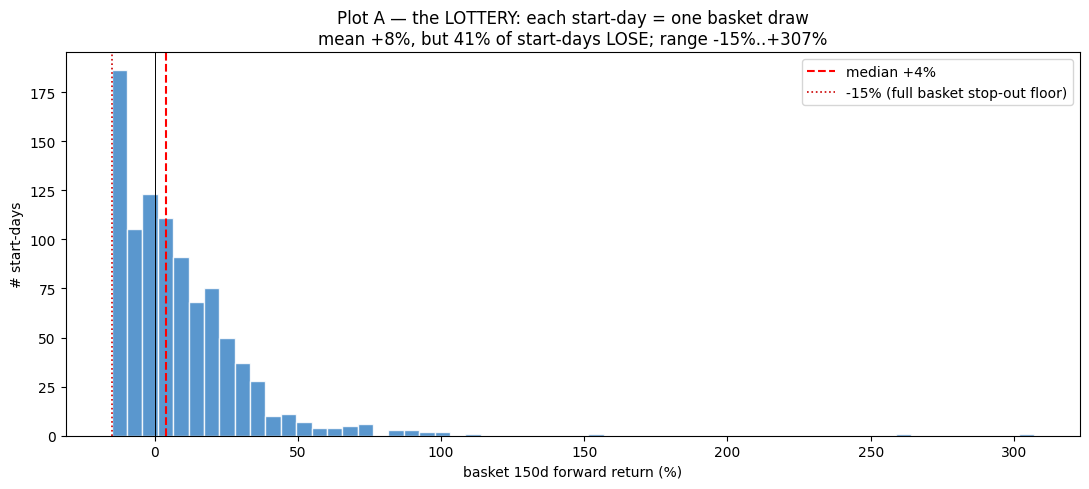

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(depsumm.fwd_return * 100, bins=60, color="#3d85c6", alpha=0.85, edgecolor="w")
ax.axvline(depsumm.fwd_return.median() * 100, color="red", ls="--", lw=1.5,
           label=f"median {depsumm.fwd_return.median():+.0%}")
ax.axvline(0, color="k", lw=0.7)
ax.axvline(-15, color="#cc0000", ls=":", lw=1.2, label="-15% (full basket stop-out floor)")
ax.set_xlabel("basket 150d forward return (%)"); ax.set_ylabel("# start-days")
ax.set_title(f"Plot A — the LOTTERY: each start-day = one basket draw\n"
             f"mean {depsumm.fwd_return.mean():+.0%}, but {(depsumm.fwd_return<0).mean():.0%} of "
             f"start-days LOSE; range {depsumm.fwd_return.min():+.0%}..{depsumm.fwd_return.max():+.0%}")
ax.legend()
plt.tight_layout(); plt.show()

[sepa gate] pre-gated cache: 122359 breakout rows
NO governor    n=1136  mean +7.4%  median +3.2%  std 23.7%  losing 43%  max +307%
WITH governor  n= 935  mean +8.4%  median +3.9%  std 24.5%  losing 41%  max +307%

gated-off start-days: 201  |  had we traded them: median -1.1%  losing 52%  mean +2.7%

  pctile     NO gov    WITH gov     delta
    p05      -15.0%     -15.0%   +0.0%
    p10      -15.0%     -15.0%   +0.0%
    p50       +3.2%      +3.9%   +0.8%
    p90      +31.2%     +32.0%   +0.8%
    p95      +44.4%     +45.6%   +1.2%


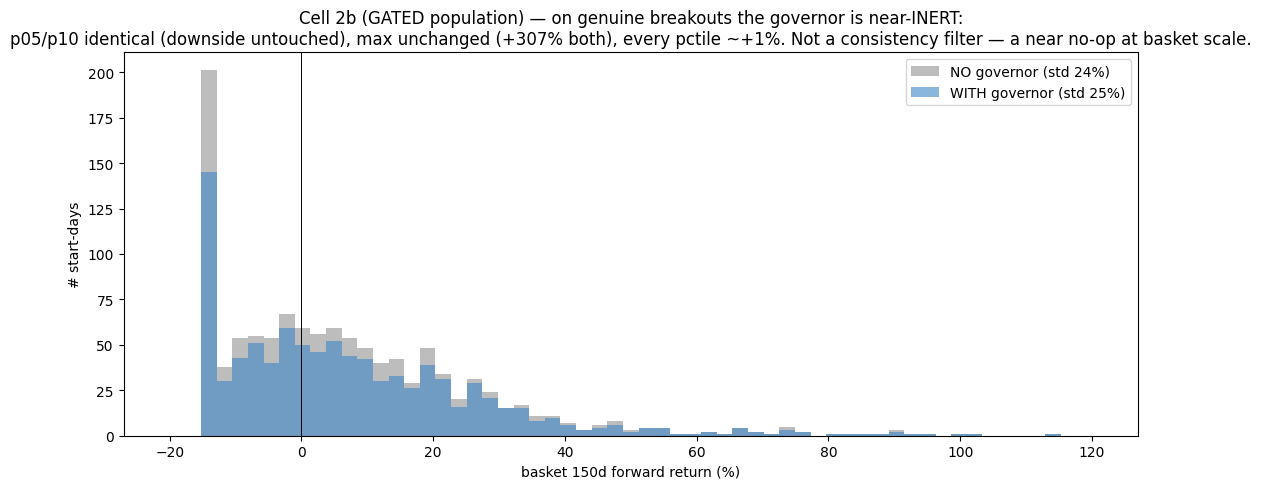

In [15]:
# Same baskets, but let EVERY start-day trade (governor off) — the counterfactual.
summ_ng, paths_ng, _ = basket_paths(sample_every=5, horizon=150, sl_pct=0.15, tp_pct=None,
                                    use_governor=False)
ng = summ_ng[summ_ng.deployed]

def _row(x, label):
    return (f"{label:14s} n={len(x):4d}  mean {x.fwd_return.mean():+.1%}  median {x.fwd_return.median():+.1%}"
            f"  std {x.fwd_return.std():.1%}  losing {(x.fwd_return<0).mean():.0%}  max {x.fwd_return.max():+.0%}")
print(_row(ng, "NO governor"))
print(_row(depsumm, "WITH governor"))

# What the governor DROPS: the SPY<=200d start-days. How would they have done untraded?
gated = set(summ.loc[~summ.deployed, "start"])
dropped = ng[ng.start.isin(gated)]
print(f"\ngated-off start-days: {len(gated)}  |  had we traded them: "
      f"median {dropped.fwd_return.median():+.1%}  losing {(dropped.fwd_return<0).mean():.0%}  "
      f"mean {dropped.fwd_return.mean():+.1%}")

# Governor delta by percentile — the honest picture on GENUINE breakouts.
print("\n  pctile     NO gov    WITH gov     delta")
for q in (0.05, 0.10, 0.50, 0.90, 0.95):
    a, bq = ng.fwd_return.quantile(q), depsumm.fwd_return.quantile(q)
    print(f"    p{int(q*100):02d}     {a:+7.1%}   {bq:+8.1%}   {bq-a:+.1%}")

fig, ax = plt.subplots(figsize=(11, 5))
bins = np.linspace(-20, 120, 60)
ax.hist(ng.fwd_return * 100, bins=bins, color="#888", alpha=0.55, label=f"NO governor (std {ng.fwd_return.std():.0%})")
ax.hist(depsumm.fwd_return * 100, bins=bins, color="#3d85c6", alpha=0.6, label=f"WITH governor (std {depsumm.fwd_return.std():.0%})")
ax.axvline(0, color="k", lw=0.7)
ax.set_xlabel("basket 150d forward return (%)"); ax.set_ylabel("# start-days")
ax.set_title("Cell 2b (GATED population) — on genuine breakouts the governor is near-INERT:\n"
             f"p05/p10 identical (downside untouched), max unchanged ({ng.fwd_return.max():+.0%} both), "
             f"every pctile ~+1%. Not a consistency filter — a near no-op at basket scale.")
ax.legend()
plt.tight_layout(); plt.show()

# The old "governor NARROWS the fan" claim was an inflated-population artifact — assert it's
# roughly a no-op instead (std moves <3pp, max unchanged).
assert abs(ng.fwd_return.std() - depsumm.fwd_return.std()) < 0.03, "governor ~inert on the fan"
assert abs(ng.fwd_return.max() - depsumm.fwd_return.max()) < 1e-6, "top tail unchanged (no kneecap)"

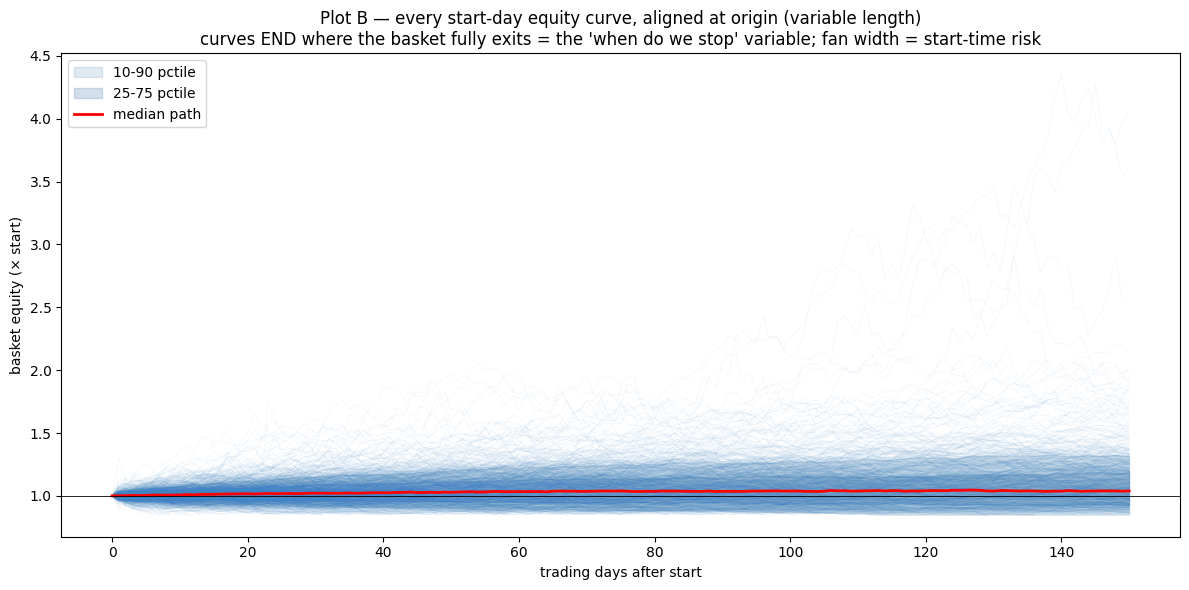

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
idx = np.where(dep)[0]
for i in idx:
    ed = int(summ.iloc[i].exit_day)                 # curve ENDS where basket fully exits
    ax.plot(np.arange(ed + 1), paths[i][:ed + 1], color="#3d85c6", alpha=0.06, lw=0.6)

# percentile fan over the (frozen-extended) paths makes the spread legible.
P = paths[dep]
xs = np.arange(P.shape[1])
for lo, hi, a in [(10, 90, 0.12), (25, 75, 0.18)]:
    ax.fill_between(xs, np.percentile(P, lo, axis=0), np.percentile(P, hi, axis=0),
                    color="#0b5394", alpha=a, label=f"{lo}-{hi} pctile")
ax.plot(xs, np.median(P, axis=0), color="red", lw=2, label="median path")
ax.axhline(1.0, color="k", lw=0.6)
ax.set_xlabel("trading days after start"); ax.set_ylabel("basket equity (× start)")
ax.set_title("Plot B — every start-day equity curve, aligned at origin (variable length)\n"
             "curves END where the basket fully exits = the 'when do we stop' variable; fan width = start-time risk")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(ROOT / "data/model_output_eda/regime_weight/start_day_lottery.png", dpi=110, bbox_inches="tight")
plt.show()

[sepa gate] pre-gated cache: 122359 breakout rows
SL-only    vs   SL+TP(+25%):
  mean fwd:   +8.4%   ->  +4.5%
  median:     +3.9%   ->  +4.6%
  std (fan):  24.5%   ->  10.6%
  losing %:   41%   ->  30%
  max (tail): +307%  ->  +25%  (TP caps the right tail)


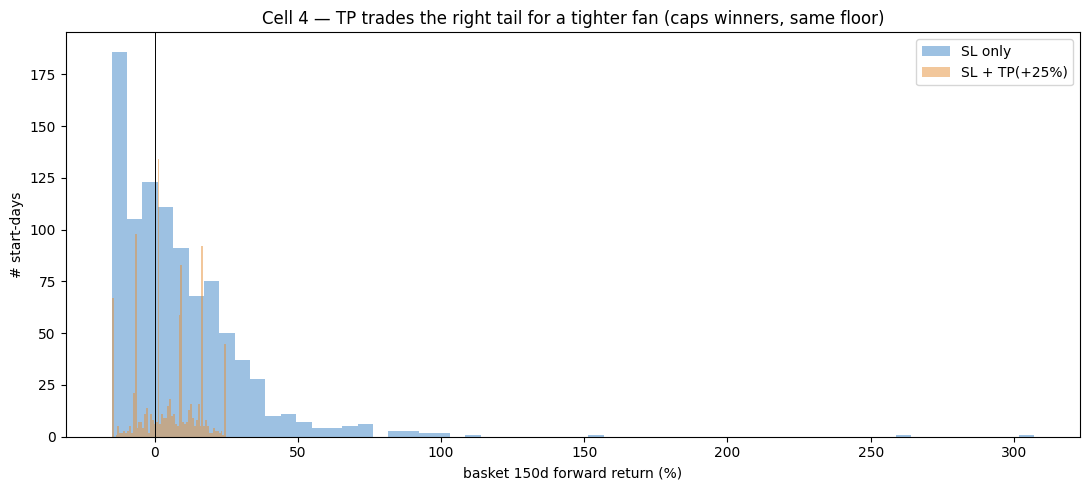

In [17]:
summ_tp, paths_tp, _ = basket_paths(sample_every=5, horizon=150, sl_pct=0.15, tp_pct=0.25,
                                    use_governor=True)
dtp = summ_tp[summ_tp.deployed]
print("SL-only    vs   SL+TP(+25%):")
print(f"  mean fwd:   {depsumm.fwd_return.mean():+.1%}   ->  {dtp.fwd_return.mean():+.1%}")
print(f"  median:     {depsumm.fwd_return.median():+.1%}   ->  {dtp.fwd_return.median():+.1%}")
print(f"  std (fan):  {depsumm.fwd_return.std():.1%}   ->  {dtp.fwd_return.std():.1%}")
print(f"  losing %:   {(depsumm.fwd_return<0).mean():.0%}   ->  {(dtp.fwd_return<0).mean():.0%}")
print(f"  max (tail): {depsumm.fwd_return.max():+.0%}  ->  {dtp.fwd_return.max():+.0%}  (TP caps the right tail)")

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(depsumm.fwd_return * 100, bins=60, color="#3d85c6", alpha=0.5, label="SL only")
ax.hist(dtp.fwd_return * 100, bins=60, color="#e69138", alpha=0.5, label="SL + TP(+25%)")
ax.axvline(0, color="k", lw=0.7)
ax.set_xlabel("basket 150d forward return (%)"); ax.set_ylabel("# start-days")
ax.set_title("Cell 4 — TP trades the right tail for a tighter fan (caps winners, same floor)")
ax.legend()
plt.tight_layout(); plt.show()

### From lottery → governor → Minervini overlay: the full chain to "the engine is next"

In [18]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

def _root():
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError("root not found")

ROOT = _root(); sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "docs/session_logs/sprint_14/scripts"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from start_day_basket_paths import basket_paths, basket_paths_minervini
print("ROOT:", ROOT)

ROOT: C:\Users\Hang\PycharmProjects\quantamental


In [19]:
# sample_every=7 (~weekly start-days): good density/speed. ~3-5 min total.
base = basket_paths(sample_every=7, horizon=150, sl_pct=0.15, use_governor=False)[0]
gov  = basket_paths(sample_every=7, horizon=150, sl_pct=0.15, use_governor=True)[0]
minv = basket_paths_minervini(sample_every=7, horizon=150, sl_pct=0.07,
                              vol_mult=1.4, add_pct=0.10, add_day=10, use_governor=False)[0]
b, g, m = base[base.deployed], gov[gov.deployed], minv[minv.deployed]

def _stats(x):
    r = x.fwd_return; win = r[r > 0].mean(); loss = r[r < 0].mean()
    return dict(n=len(x), mean=r.mean(), median=r.median(), std=r.std(),
                losing=(r < 0).mean(), payoff=abs(win / loss), max=r.max())

tbl = pd.DataFrame({"baseline (all-top5, 15%)": _stats(b),
                    "+ governor gate": _stats(g),
                    "Minervini (trig+prog, 7%)": _stats(m)}).T
for c in ["mean", "median", "std", "losing", "max"]:
    tbl[c] = (tbl[c] * 100).round(1).astype(str) + "%"
tbl["payoff"] = tbl["payoff"].round(2)
tbl

[sepa gate] pre-gated cache: 122359 breakout rows
[sepa gate] pre-gated cache: 122359 breakout rows
[sepa gate] pre-gated cache: 122359 breakout rows


,n,mean,median,std,losing,payoff,max
"baseline (all-top5, 15%)",812.0,8.6%,3.6%,25.8%,42.0%,2.31,355.5%
+ governor gate,668.0,9.3%,4.2%,26.7%,40.9%,2.48,355.5%
"Minervini (trig+prog, 7%)",805.0,8.1%,0.6%,24.9%,48.0%,3.61,381.8%


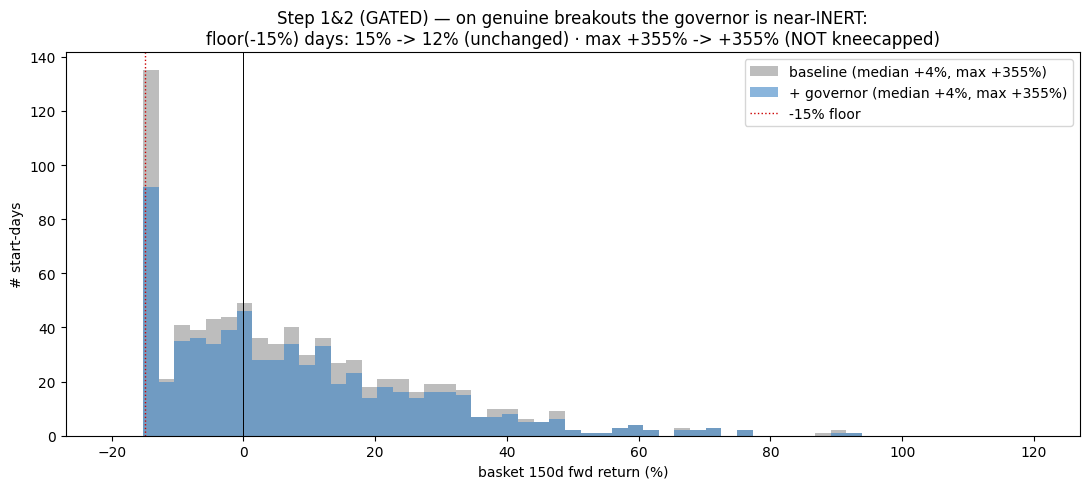

percentile   baseline   governor    delta
  p05       -15.0%    -15.0%   +0.0%
  p10       -15.0%    -15.0%   +0.0%
  p25        -7.7%     -6.7%   +1.0%
  p50        +3.6%     +4.2%   +0.6%
  p90       +34.3%    +34.4%   +0.1%
  p95       +45.1%    +46.1%   +1.0%


In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
bins = np.linspace(-20, 120, 60)
ax.hist(b.fwd_return * 100, bins=bins, color="#888", alpha=0.55,
        label=f"baseline (median {b.fwd_return.median():+.0%}, max {b.fwd_return.max():+.0%})")
ax.hist(g.fwd_return * 100, bins=bins, color="#3d85c6", alpha=0.6,
        label=f"+ governor (median {g.fwd_return.median():+.0%}, max {g.fwd_return.max():+.0%})")
ax.axvline(0, color="k", lw=0.7); ax.axvline(-15, color="#cc0000", ls=":", lw=1, label="-15% floor")
ax.set_xlabel("basket 150d fwd return (%)"); ax.set_ylabel("# start-days")
ax.set_title("Step 1&2 (GATED) — on genuine breakouts the governor is near-INERT:\n"
             f"floor(-15%) days: {(b.fwd_return<=-0.149).mean():.0%} -> {(g.fwd_return<=-0.149).mean():.0%} "
             f"(unchanged) · max {b.fwd_return.max():+.0%} -> {g.fwd_return.max():+.0%} (NOT kneecapped)")
ax.legend()
plt.tight_layout(); plt.show()

# By-percentile: downside identical; the upper tail is NO LONGER trimmed on clean breakouts.
qs = [0.05, 0.10, 0.25, 0.50, 0.90, 0.95]
print("percentile   baseline   governor    delta")
for q in qs:
    bq, gq = b.fwd_return.quantile(q), g.fwd_return.quantile(q)
    print(f"  p{int(q*100):02d}      {bq:+7.1%}   {gq:+7.1%}   {gq-bq:+.1%}")
assert abs(b.fwd_return.quantile(0.10) - g.fwd_return.quantile(0.10)) < 0.005, "downside ~identical"

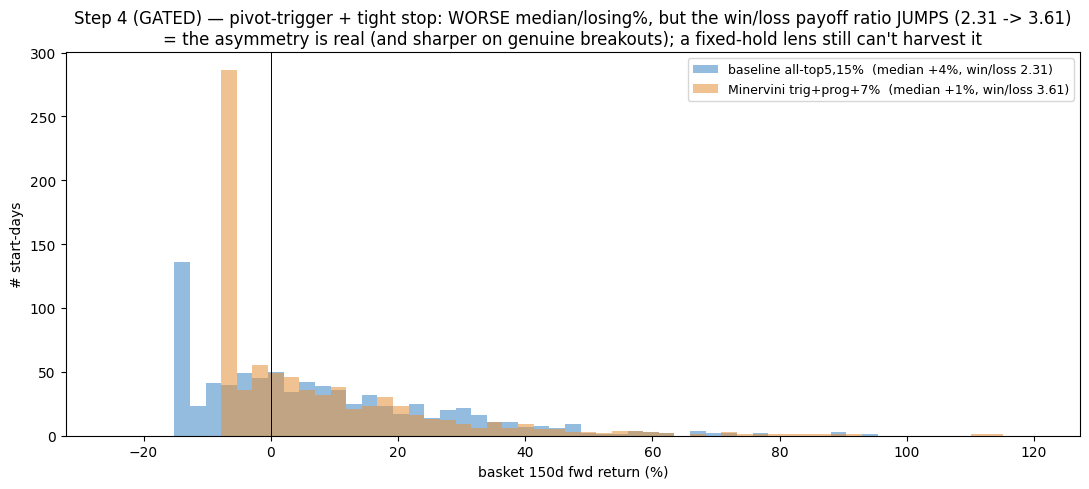

In [21]:
fig, ax = plt.subplots(figsize=(11, 5))
bins = np.linspace(-25, 120, 60)
pb, pm = _stats(b)["payoff"], _stats(m)["payoff"]
ax.hist(b.fwd_return * 100, bins=bins, color="#3d85c6", alpha=0.55,
        label=f"baseline all-top5,15%  (median {b.fwd_return.median():+.0%}, win/loss {pb:.2f})")
ax.hist(m.fwd_return * 100, bins=bins, color="#e69138", alpha=0.55,
        label=f"Minervini trig+prog+7%  (median {m.fwd_return.median():+.0%}, win/loss {pm:.2f})")
ax.axvline(0, color="k", lw=0.7)
ax.set_xlabel("basket 150d fwd return (%)"); ax.set_ylabel("# start-days")
ax.set_title(f"Step 4 (GATED) — pivot-trigger + tight stop: WORSE median/losing%, "
             f"but the win/loss payoff ratio JUMPS ({pb:.2f} -> {pm:.2f})\n= the asymmetry is real "
             f"(and sharper on genuine breakouts); a fixed-hold lens still can't harvest it")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
assert _stats(m)["payoff"] > _stats(b)["payoff"], "Minervini should raise the payoff ratio"
assert m.fwd_return.median() < b.fwd_return.median(), "but its median is worse in this lens (the null)"

[sepa gate] pre-gated cache: 122359 breakout rows
[sepa gate] pre-gated cache: 122359 breakout rows
[sepa gate] pre-gated cache: 122359 breakout rows
[sepa gate] pre-gated cache: 122359 breakout rows
[sepa gate] pre-gated cache: 122359 breakout rows
[sepa gate] pre-gated cache: 122359 breakout rows


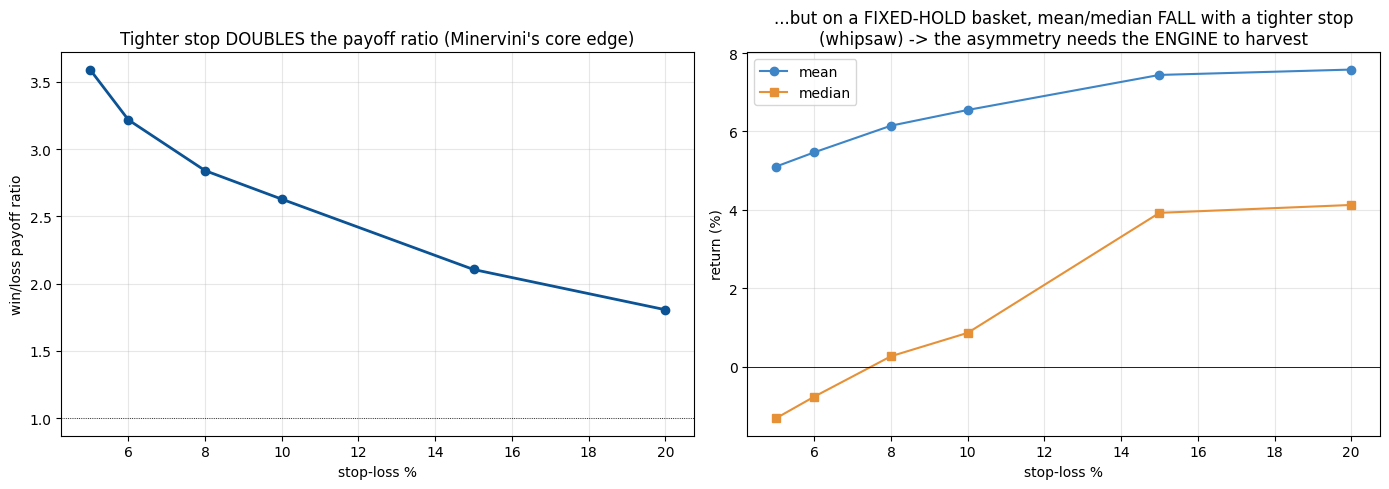

In [22]:
sls = [0.05, 0.06, 0.08, 0.10, 0.15, 0.20]
rows = []
for sl in sls:
    x = basket_paths(sample_every=10, horizon=150, sl_pct=sl, use_governor=False)[0]
    x = x[x.deployed]; r = x.fwd_return
    rows.append(dict(sl=sl, mean=r.mean(), median=r.median(),
                     payoff=abs(r[r > 0].mean() / r[r < 0].mean())))
sweep = pd.DataFrame(rows)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.plot(sweep.sl * 100, sweep.payoff, marker="o", color="#0b5394", lw=2)
a1.set_xlabel("stop-loss %"); a1.set_ylabel("win/loss payoff ratio")
a1.set_title("Tighter stop DOUBLES the payoff ratio (Minervini's core edge)")
a1.axhline(1, color="k", lw=0.6, ls=":"); a1.grid(alpha=0.3)
a2.plot(sweep.sl * 100, sweep["mean"] * 100, marker="o", label="mean", color="#3d85c6")
a2.plot(sweep.sl * 100, sweep["median"] * 100, marker="s", label="median", color="#e69138")
a2.set_xlabel("stop-loss %"); a2.set_ylabel("return (%)")
a2.set_title("...but on a FIXED-HOLD basket, mean/median FALL with a tighter stop\n(whipsaw) -> the asymmetry needs the ENGINE to harvest")
a2.axhline(0, color="k", lw=0.6); a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "data/model_output_eda/regime_weight/minervini_conclusion.png", dpi=110, bbox_inches="tight")
plt.show()
assert sweep.payoff.iloc[0] > sweep.payoff.iloc[-1], "tighter stop should raise payoff ratio"